# 02 - Baselines

TF-IDF + Logistic Regression and TF-IDF + Linear SVM / Naive Bayes, plus the agreement experiments (all data vs high agreement only vs weighted loss).

Everything is tuned on val. Test is only used once at the end for the final models.

Runs fine on a CPU runtime.

In [1]:
import os, sys

# on colab clone the repo, locally just move up from notebooks/
if "google.colab" in sys.modules:
    if not os.path.exists("/content/NLP_and_Language_technologies-Group-9"):
        !git clone https://github.com/Samkwizera/NLP_and_Language_technologies-Group-9.git /content/NLP_and_Language_technologies-Group-9
    %cd /content/NLP_and_Language_technologies-Group-9
    !pip install -q -r requirements.txt
    # csvs aren't in git, so copy them from drive (MyDrive/nlp_data/)
    from google.colab import drive
    drive.mount("/content/drive")
    import glob, shutil
    # zindi downloads come as "train (1).csv" etc, the code expects Train.csv / Test.csv
    for f in glob.glob("/content/drive/MyDrive/nlp_data/*.csv"):
        name = os.path.basename(f).lower()
        if name.startswith("train"):
            shutil.copy(f, "data/Train.csv")
        elif name.startswith("test"):
            shutil.copy(f, "data/Test.csv")
    if not os.path.exists("data/Train.csv"):
        raise FileNotFoundError("put the train/test csvs in MyDrive/nlp_data/")
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
os.listdir("data")

Cloning into '/content/NLP_and_Language_technologies-Group-9'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 77 (delta 30), reused 70 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (77/77), 330.37 KiB | 6.35 MiB/s, done.
Resolving deltas: 100% (30/30), done.
/content/NLP_and_Language_technologies-Group-9
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.1/183.1 kB 7.5 MB/s eta 0:00:00
Mounted at /content/drive


['Test.csv', 'Train.csv', 'README.md']

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.split import load_split
from src.utils import set_seed, ensure_dirs, add_takeaway
from src.evaluate import compute_metrics, plot_confusion_matrix, plot_learning_curve, export_errors
from src.models.baselines import run_experiment, learning_curve, confidence

set_seed()
ensure_dirs()
pd.set_option("display.max_colwidth", 120)

train, val, test = load_split()
for name, df in [("train", train), ("val", val), ("test", test)]:
    print(name, len(df), (df["label"].value_counts(normalize=True).sort_index() * 100).round(1).tolist())

train 6995 [10.4, 49.1, 40.6]
val 1502 [10.3, 49.3, 40.5]
test 1503 [10.6, 48.9, 40.5]


## 1. The shared split

The split is in `splits/split_seed42.csv` (tweet ids only) and everyone loads it with `load_split()`. It's 70/15/15, seed 42, stratified on label and agreement together, and all copies of a duplicated tweet are in the same set, so nothing leaks from train into val/test. To rebuild it: `python -m src.split`.

## 2. Baseline experiments

Each run is logged to `results/experiments.csv`. We also keep per-class F1 here since the log only has the main metrics.

In [3]:
runs = [
    dict(exp_id="B1", model="logreg", features="word",
         change="word 1-2 grams only", reason="simplest starting point"),
    dict(exp_id="B2", model="logreg", features="word+char",
         change="added char 2-5 grams", reason="half the vocab appears once, char n-grams should help with typos and rare words"),
    dict(exp_id="B3", model="logreg", features="word+char", class_weight="balanced",
         change="balanced class weights", reason="negative is only 10% of the data"),
    dict(exp_id="N1", model="nb", features="word+char", C=0.3,
         change="complement naive bayes", reason="nb is a common strong baseline for short text, complement nb handles imbalance better"),
    dict(exp_id="S1", model="svm", features="word+char", class_weight="balanced", C=0.1,
         change="linear svm instead of logreg", reason="linear svms usually do well on sparse tf-idf features"),
]

results = {}
for run in runs:
    pipe, preds, m = run_experiment(train_df=train, eval_df=val, **run)
    results[run["exp_id"]] = m
    print(run["exp_id"], m)

pd.DataFrame(results).T

B1 {'macro_f1': 0.5816, 'accuracy': 0.7483, 'rmse': 0.6719, 'f1_negative': 0.1839, 'f1_neutral': 0.8169, 'f1_positive': 0.7439}
B2 {'macro_f1': 0.6241, 'accuracy': 0.7623, 'rmse': 0.6446, 'f1_negative': 0.2843, 'f1_neutral': 0.8213, 'f1_positive': 0.7666}
B3 {'macro_f1': 0.6733, 'accuracy': 0.7497, 'rmse': 0.7043, 'f1_negative': 0.4477, 'f1_neutral': 0.8227, 'f1_positive': 0.7494}
N1 {'macro_f1': 0.6097, 'accuracy': 0.7304, 'rmse': 0.701, 'f1_negative': 0.3014, 'f1_neutral': 0.7906, 'f1_positive': 0.7371}
S1 {'macro_f1': 0.6737, 'accuracy': 0.7597, 'rmse': 0.6724, 'f1_negative': 0.4397, 'f1_neutral': 0.824, 'f1_positive': 0.7573}


,macro_f1,accuracy,rmse,f1_negative,f1_neutral,f1_positive
B1,0.5816,0.7483,0.6719,0.1839,0.8169,0.7439
B2,0.6241,0.7623,0.6446,0.2843,0.8213,0.7666
B3,0.6733,0.7497,0.7043,0.4477,0.8227,0.7494
N1,0.6097,0.7304,0.7010,0.3014,0.7906,0.7371
S1,0.6737,0.7597,0.6724,0.4397,0.8240,0.7573


### Tuning C

Small grid on val for the two linear models (both with word+char features and balanced weights).

In [4]:
grid = {"logreg": [0.3, 1, 3, 10, 30], "svm": [0.03, 0.1, 0.3, 1]}
tuning = []
for model, Cs in grid.items():
    for C in Cs:
        _, _, m = run_experiment("tmp", train, val, model=model, C=C, class_weight="balanced", log=False)
        tuning.append({"model": model, "C": C, **m})
tuning = pd.DataFrame(tuning)
tuning

,model,C,macro_f1,accuracy,rmse,f1_negative,f1_neutral,f1_positive
0,logreg,0.30,0.6674,0.7390,0.7298,0.4462,0.8200,0.7361
1,logreg,1.00,0.6733,0.7497,0.7043,0.4477,0.8227,0.7494
2,logreg,3.00,0.6689,0.7517,0.6856,0.4345,0.8188,0.7534
3,logreg,10.00,0.6595,0.7457,0.6827,0.4218,0.8104,0.7464
4,logreg,30.00,0.6442,0.7357,0.6943,0.3931,0.8027,0.7368
5,svm,0.03,0.6588,0.7537,0.6753,0.4093,0.8196,0.7476
6,svm,0.10,0.6737,0.7597,0.6724,0.4397,0.8240,0.7573
7,svm,0.30,0.6690,0.7603,0.6689,0.4199,0.8232,0.7639
8,svm,1.00,0.6395,0.7364,0.6924,0.3782,0.8030,0.7372


In [5]:
best_C = tuning.loc[tuning.groupby("model")["macro_f1"].idxmax()].set_index("model")["C"].to_dict()
print(best_C)

for exp_id, model in [("B4", "logreg"), ("S2", "svm")]:
    _, _, m = run_experiment(exp_id, train, val, model=model, C=best_C[model], class_weight="balanced",
                             change=f"tuned C={best_C[model]}", reason="grid search on val macro-F1")
    results[exp_id] = m

pd.DataFrame(results).T.sort_values("macro_f1", ascending=False)

{'logreg': 1.0, 'svm': 0.1}


,macro_f1,accuracy,rmse,f1_negative,f1_neutral,f1_positive
S1,0.6737,0.7597,0.6724,0.4397,0.8240,0.7573
S2,0.6737,0.7597,0.6724,0.4397,0.8240,0.7573
B3,0.6733,0.7497,0.7043,0.4477,0.8227,0.7494
B4,0.6733,0.7497,0.7043,0.4477,0.8227,0.7494
B2,0.6241,0.7623,0.6446,0.2843,0.8213,0.7666
N1,0.6097,0.7304,0.7010,0.3014,0.7906,0.7371
B1,0.5816,0.7483,0.6719,0.1839,0.8169,0.7439


**Notes**

- Char n-grams help: macro-F1 goes from 0.582 to 0.624 and negative F1 from 0.18 to 0.28. This fits the EDA, where half the vocab only appears once.
- Class weights are the biggest single gain: 0.673 macro-F1 and negative F1 up to 0.45. Accuracy drops a bit (0.762 to 0.750) and RMSE goes up (0.645 to 0.704), because the model now predicts more negatives and some of those are -1 vs 1 mistakes, which RMSE punishes the most. That's the trade-off we expected, and why macro-F1 is our main metric and not accuracy or RMSE.
- Complement NB is clearly worse (0.610), mostly on negative.
- LogReg and SVM are basically tied (0.673 vs 0.674).
- Tuning C didn't change anything. The best values were C=1 for LogReg (the default) and C=0.1 for SVM (what S1 already used), so B4 and S2 are the same as B3 and S1. Bigger C makes both worse (LogReg with C=30 drops to 0.644), so they overfit when regularisation is weaker.

## 3. Agreement experiments

Same setup as the tuned models, only the training data changes. Val stays the same (all agreement levels) so the scores are comparable.

- `all`: every training tweet
- `high`: only agreement = 1
- `drop_333`: drop the 239-ish no-majority tweets (all labelled negative)
- `weighted`: keep everything, weight each tweet by its agreement in the loss

In [6]:
modes = {
    "all": ("all training data", "reference for the agreement runs"),
    "high": ("only agreement = 1", "cleaner labels, but loses ~63% of negatives"),
    "drop_333": ("dropped agreement = 0.333", "those tweets had no majority and were all defaulted to negative"),
    "weighted": ("loss weighted by agreement", "keep all data but trust uncertain labels less"),
}

agree_results = []
i = 1
for model in ["logreg", "svm"]:
    for mode, (change, reason) in modes.items():
        exp_id = f"A{i}"
        _, _, m = run_experiment(exp_id, train, val, model=model, C=best_C[model], class_weight="balanced",
                                 agreement=mode, change=f"{model}: {change}", reason=reason)
        agree_results.append({"exp_id": exp_id, "model": model, "agreement": mode, **m})
        i += 1

agree_results = pd.DataFrame(agree_results)
agree_results

,exp_id,model,agreement,macro_f1,accuracy,rmse,f1_negative,f1_neutral,f1_positive
0,A1,logreg,all,0.6733,0.7497,0.7043,0.4477,0.8227,0.7494
1,A2,logreg,high,0.6851,0.7617,0.6634,0.4828,0.8219,0.7508
2,A3,logreg,drop_333,0.6793,0.7610,0.6729,0.4512,0.8235,0.7631
3,A4,logreg,weighted,0.6799,0.7617,0.6827,0.4487,0.8303,0.7608
4,A5,svm,all,0.6737,0.7597,0.6724,0.4397,0.8240,0.7573
5,A6,svm,high,0.6554,0.7583,0.6674,0.3963,0.8204,0.7496
6,A7,svm,drop_333,0.6707,0.7663,0.6599,0.4190,0.8273,0.7659
7,A8,svm,weighted,0.6741,0.7670,0.6563,0.4327,0.8277,0.7619


In [7]:
agree_results.pivot(index="agreement", columns="model", values=["macro_f1", "f1_negative"]).loc[list(modes)]

macro_f1         f1_negative        
model       logreg     svm      logreg     svm
agreement                                     
all         0.6733  0.6737      0.4477  0.4397
high        0.6851  0.6554      0.4828  0.3963
drop_333    0.6793  0.6707      0.4512  0.4190
weighted    0.6799  0.6741      0.4487  0.4327

In [8]:
# also check how each setting does on val tweets split by their agreement,
# to see if training on clean labels only helps on the easy tweets
rows = []
for model in ["logreg", "svm"]:
    for mode in modes:
        pipe, preds, _ = run_experiment("tmp", train, val, model=model, C=best_C[model],
                                        class_weight="balanced", agreement=mode, log=False)
        for a, part in val.assign(pred=preds).groupby(val["agreement"].round(3)):
            rows.append({"model": model, "agreement_mode": mode, "val_agreement": a,
                         "macro_f1": compute_metrics(part["label"], part["pred"])["macro_f1"], "n": len(part)})
pd.DataFrame(rows).pivot_table(index=["model", "agreement_mode"], columns="val_agreement", values="macro_f1")

val_agreement           0.333   0.667   1.000
model  agreement_mode                        
logreg all             0.1481  0.5864  0.7423
       drop_333        0.0976  0.6054  0.7548
       high            0.0684  0.5867  0.7996
       weighted        0.1111  0.6017  0.7546
svm    all             0.0976  0.5890  0.7584
       drop_333        0.0684  0.5881  0.7640
       high            0.0526  0.5528  0.7787
       weighted        0.0833  0.5890  0.7668

**Notes**

- The two models don't agree. LogReg does best when trained only on agreement = 1 (0.685, negative F1 0.48), even though that throws away 63% of the negatives. For SVM the same setting is the worst (0.655, negative F1 0.40), and weighting is basically tied with all data (0.6741 vs 0.6737).
- All the differences are 1-2 points, and val only has about 155 negative tweets, so a handful of tweets can move these numbers. We can't say one agreement setting is clearly better from this.
- The breakdown by val agreement is more useful. Every model is close to useless on the 35 val tweets with agreement 0.333 (macro-F1 between 0.05 and 0.15), so those labels really can't be learned. Training on agreement = 1 only makes the model better on the clear tweets (LogReg goes from 0.742 to 0.800 on agreement 1.0 tweets) but worse on the unclear ones.
- So label noise puts a ceiling on the scores, but for these models how we handle agreement matters less than class weights and char n-grams.

## 4. Final baseline models

For each model we keep the agreement setting with the best val macro-F1.

In [9]:
best = agree_results.loc[agree_results.groupby("model")["macro_f1"].idxmax()].set_index("model")
final = {model: dict(model=model, C=best_C[model], class_weight="balanced", agreement=best.loc[model, "agreement"])
         for model in ["logreg", "svm"]}
final

{'logreg': {'model': 'logreg',
  'C': 1.0,
  'class_weight': 'balanced',
  'agreement': 'high'},
 'svm': {'model': 'svm',
  'C': 0.1,
  'class_weight': 'balanced',
  'agreement': 'weighted'}}

logreg {'macro_f1': 0.6851, 'accuracy': 0.7617, 'rmse': 0.6634, 'f1_negative': 0.4828, 'f1_neutral': 0.8219, 'f1_positive': 0.7508}


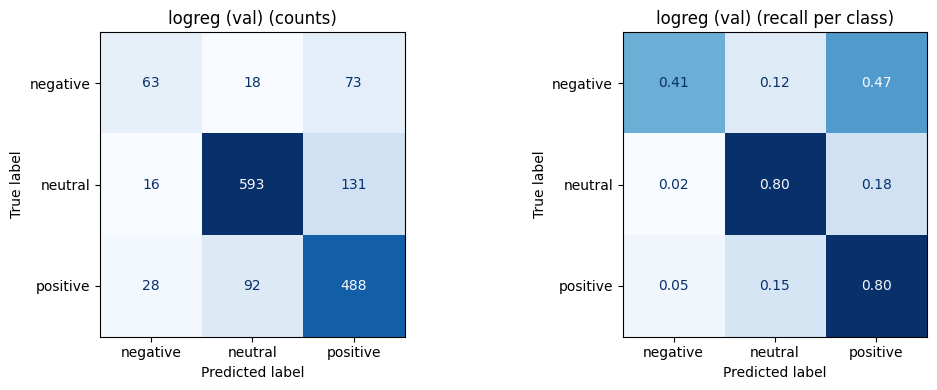

svm {'macro_f1': 0.6741, 'accuracy': 0.767, 'rmse': 0.6563, 'f1_negative': 0.4327, 'f1_neutral': 0.8277, 'f1_positive': 0.7619}


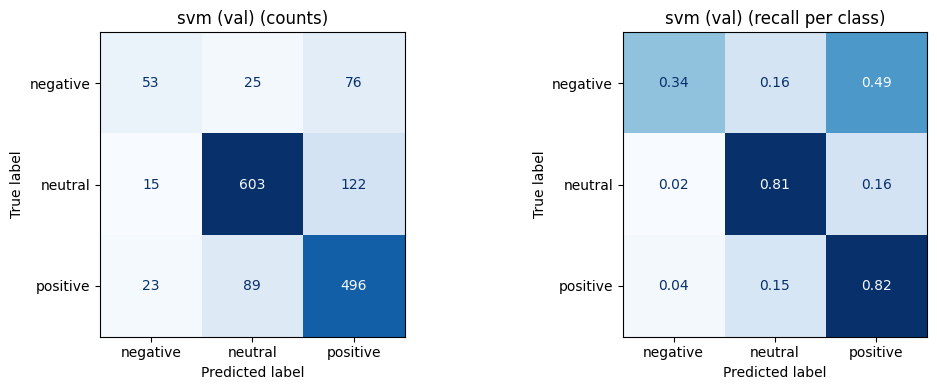

In [10]:
fitted = {}
for model, cfg in final.items():
    pipe, preds, m = run_experiment("tmp", train, val, log=False, **cfg)
    fitted[model] = pipe
    print(model, m)
    plot_confusion_matrix(val["label"], preds, f"{model} (val)", name=f"baseline_{model}_val_cm")

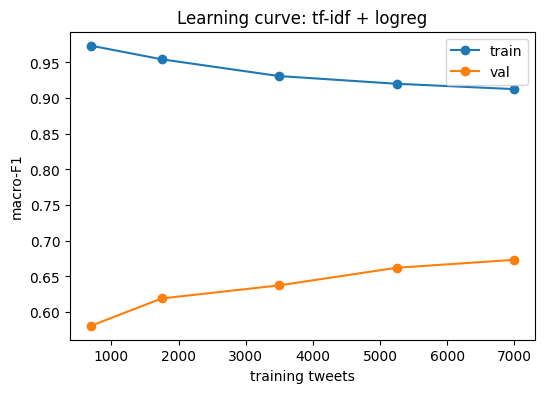

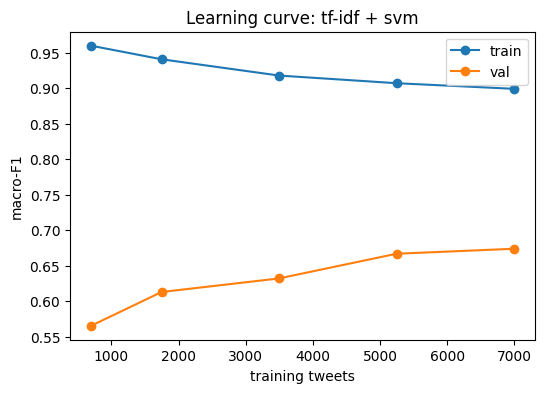

In [11]:
for model, cfg in final.items():
    sizes, tr, va = learning_curve(train, val, model=model, C=cfg["C"], class_weight="balanced")
    plot_learning_curve(sizes, tr, va, f"Learning curve: tf-idf + {model}", name=f"baseline_{model}_learning_curve")

**Notes**

- The final picks are LogReg trained on agreement = 1 (val 0.685) and SVM with the agreement-weighted loss (val 0.674). The SVM pick is only 0.0004 ahead of plain all-data training, so it's really a tie.
- Both learning curves look the same. Val macro-F1 is still going up at full size (about 0.57-0.58 to 0.67), so more data would help. Train stays around 0.90, which is a big gap, so the models are overfitting to words they've seen and don't generalise well.
- In the confusion matrices, neutral and positive are recognised about 80% of the time, but negative only about 40%, and most of the missed negatives go to positive, not neutral.

## 5. Error analysis (val)

In [12]:
errors = {}
for model, pipe in fitted.items():
    preds = pipe.predict(val["safe_text"])
    errors[model] = export_errors(val, preds, confidence(pipe, val["safe_text"]), f"baseline_{model}")
    print(model, len(errors[model]), "errors saved to results/errors/")

err = errors["logreg"]
pd.crosstab(err["true"], err["predicted"])

logreg 358 errors saved to results/errors/
svm 350 errors saved to results/errors/


predicted,-1,0,1
true,,,
-1,0,18,73
0,16,0,131
1,28,92,0


In [13]:
# error rate by annotator agreement, hashtags and replies
v = val.assign(pred=fitted["logreg"].predict(val["safe_text"]))
v["wrong"] = v["pred"] != v["label"]
v["has_hashtag"] = v["safe_text"].str.contains("#")
v["has_user"] = v["safe_text"].str.contains("<user>", regex=False)
for col in ["agreement", "has_hashtag", "has_user"]:
    print(v.groupby(v[col].round(3) if col == "agreement" else v[col])["wrong"].agg(["mean", "size"]).round(3), "\n")

            mean  size
agreement             
0.333      0.886    35
0.667      0.358   595
1.000      0.131   872 

              mean  size
has_hashtag             
False        0.251  1130
True         0.199   372 

           mean  size
has_user             
False     0.227   909
True      0.256   593 



In [14]:
# most confident mistakes
err[["text", "true", "predicted", "agreement", "confidence"]].head(20)

,text,true,predicted,agreement,confidence
602,I love when people with NO kids feel the need to talk down on parents that don't vaccinate their kids,-1,1,1.000000,0.9819
59,Parents who DON'T vaccinate their kids. \nTable open for discussion .\n\n(I have a pt with measles today btw)\nSmdh,0,1,0.666667,0.9619
351,San Bernardino County Measles Exposure Warning <url>,1,0,0.666667,0.9615
803,There's little doubt where the measles outbreak came from.... <url>,1,0,0.666667,0.9576
1057,I wonder how many of these adults so against the truth of vaccine safety are fully vaxed? Hmmm. #CDCwhistleblower,1,-1,0.666667,0.9558
35,<user> or not vaccinate his kids but doesn't want others to have them,0,1,0.666667,0.9458
608,"""<user> RT <user> RT <user> For God's sake. Vaccinate your damn kids."" Even tho its the main cause of austism?",-1,1,0.666667,0.9443
305,RT <user> Kids and Teens Get Free Immunizations For Whooping Cough <url>,0,1,0.666667,0.9422
661,The person who visited Super Bowl village with measles &lt;&lt;&lt;&lt;&lt;&lt;&lt;&lt;,-1,0,0.333333,0.9416
1168,Hurt over measles lingers in small town: Four people in one family in Kearny Arizona contracted the measles while… <...,1,0,0.666667,0.9410


In [15]:
# true positive tweets predicted negative: are these the angry pro-vaccine tweets from the eda?
err[(err["true"] == 1) & (err["predicted"] == -1)][["text", "agreement", "confidence"]].head(15)

,text,agreement,confidence
1057,I wonder how many of these adults so against the truth of vaccine safety are fully vaxed? Hmmm. #CDCwhistleblower,0.666667,0.9558
1474,Came to the doctors to get my ear checked out and they gave me a vaccine shot for some disease instead 😒💉,0.666667,0.7049
1194,It definitely causes brain injury “<user> What if defending anti-vaccination beliefs causes autism?”,0.666667,0.6469
556,<user> we find out its actually based on your cultural background and that somehow we tie in vaccines causing autism...,0.666667,0.6436
369,<user> thank you for being a voice of truth in this land of corruption. The world need to see <user> and know the tr...,0.666667,0.6430
1051,"Like who the fuck says ""pumped full of mercury and other toxic substances""? it's just a small vaccine, tf",1.000000,0.6414
147,"<user> <user> My children are 27,24 &amp; 19. Completely up to date on their vaccines. I'm questioning the meningiti...",1.000000,0.6285
1498,<user>\nI thought of vaccinating my children as something I did for them &amp; all the other children. Now we need l...,1.000000,0.6175
1065,“<user> TV’s Relationship to Autism: <url> not caused by vaccines? Weird! cc: <user> and Brian emmer,0.666667,0.5834
19,<user> And the parents need to get their MMR booster shot too. They claim vaccines cause autism and other disorders....,0.666667,0.5747


**Notes**

- LogReg gets 358 of 1,502 val tweets wrong (24%). Most mistakes are neutral vs positive (131 neutral tweets predicted positive and 92 the other way round). For negatives, 73 of the 91 missed ones are predicted positive. So the model mixes up anti- and pro-vaccine tweets, which use the same words (vaccine, kids, autism, measles).
- Error rate follows annotator agreement: 89% wrong on agreement 0.333, 36% on 0.667 and 13% on 1.0. The model fails where the people labelling also disagreed.
- Tweets with a hashtag are easier (20% wrong vs 25%), which matches the EDA where some hashtags almost give away the label. Replies (`<user>`) are a bit harder (26% vs 23%).
- Many of the most confident mistakes look like label noise rather than model mistakes. "People who don't immunize their children are idiots..." and a "#vaccineswork" tweet supporting SB277 are labelled neutral and the model says positive, which looks right. Several plain news headlines ("Measles Exposure Warning", "FDA Commissioner says measles outbreak 'alarming'") are labelled positive or negative. 18 of the top 20 confident mistakes have agreement below 1.
- Positive tweets predicted as negative are mostly the stance problem from the EDA. They mention anti-vaccine claims in order to argue against them ("Vaccines do not cause autism, however...", "Even if vaccines did cause autism, so the f*** what?", "who says pumped full of mercury... it's just a small vaccine") or are sarcastic. A bag of words sees "autism" and "mercury" and says negative. This is where models that read word order and context (the RNN/CNN and transformers) should do better.

## 6. Test set

Only run once, after everything above is decided.

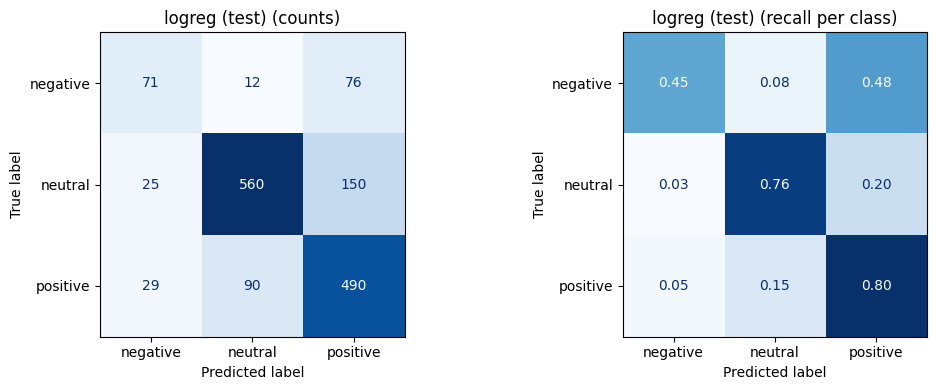

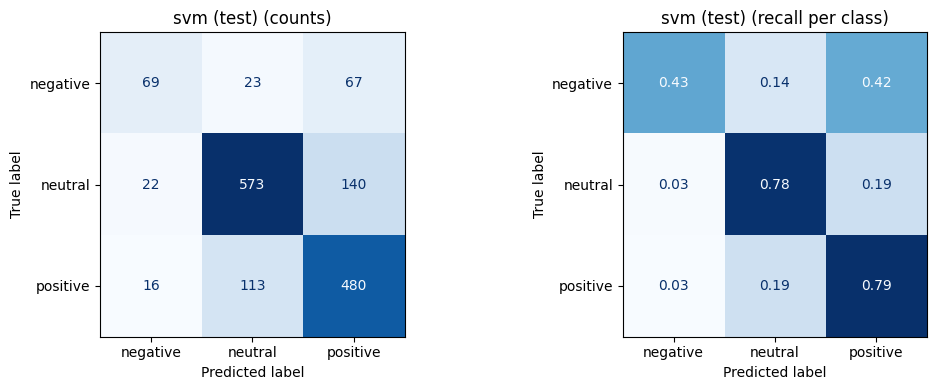

,macro_f1,accuracy,rmse,f1_negative,f1_neutral,f1_positive
logreg,0.6804,0.7458,0.6810,0.5000,0.8017,0.7396
svm,0.6844,0.7465,0.6474,0.5188,0.7936,0.7407


In [16]:
test_results = {}
for (model, cfg), exp_id in zip(final.items(), ["BT1", "BT2"]):
    _, preds, m = run_experiment(exp_id, train, test, **cfg,
                                 change=f"final {model} on test (agreement={cfg['agreement']})",
                                 reason="final evaluation of the best val config")
    test_results[model] = m
    plot_confusion_matrix(test["label"], preds, f"{model} (test)", name=f"baseline_{model}_test_cm")
pd.DataFrame(test_results).T

**Notes**

- On test, SVM gets 0.684 macro-F1 and LogReg 0.680. That's close to val (0.674 and 0.685), so we didn't overfit to val by picking settings on it. With a gap this small, the two baselines are basically equal.
- Negative F1 on test is 0.52 (SVM) and 0.50 (LogReg), slightly better than on val, but SVM still only finds about 43% of the negative tweets.
- RMSE is 0.647 (SVM) and 0.681 (LogReg). This is the number to compare with the Zindi leaderboard, but Zindi scores continuous predictions, so our hard -1/0/1 predictions are at a disadvantage there.
- These are the scores the RNN/CNN and transformer models need to beat: **macro-F1 0.684 on test**.

In [17]:
pd.read_csv(config.EXPERIMENTS_CSV)

,exp_id,member,model,change,reason,macro_f1,accuracy,rmse,takeaway
0,B1,Samuel,tfidf-word+logreg,word 1-2 grams only,simplest starting point,0.5816,0.7483,0.6719,NaN
1,B2,Samuel,tfidf-word+char+logreg,added char 2-5 grams,"half the vocab appears once, char n-grams should help with typos and rare words",0.6241,0.7623,0.6446,NaN
2,B3,Samuel,tfidf-word+char+logreg,balanced class weights,negative is only 10% of the data,0.6733,0.7497,0.7043,NaN
3,N1,Samuel,tfidf-word+char+nb,complement naive bayes,"nb is a common strong baseline for short text, complement nb handles imbalance better",0.6097,0.7304,0.7010,NaN
4,S1,Samuel,tfidf-word+char+svm,linear svm instead of logreg,linear svms usually do well on sparse tf-idf features,0.6737,0.7597,0.6724,NaN
5,B4,Samuel,tfidf-word+char+logreg,tuned C=1.0,grid search on val macro-F1,0.6733,0.7497,0.7043,NaN
6,S2,Samuel,tfidf-word+char+svm,tuned C=0.1,grid search on val macro-F1,0.6737,0.7597,0.6724,NaN
7,A1,Samuel,tfidf-word+char+logreg,logreg: all training data,reference for the agreement runs,0.6733,0.7497,0.7043,NaN
8,A2,Samuel,tfidf-word+char+logreg,logreg: only agreement = 1,"cleaner labels, but loses ~63% of negatives",0.6851,0.7617,0.6634,NaN
9,A3,Samuel,tfidf-word+char+logreg,logreg: dropped agreement = 0.333,those tweets had no majority and were all defaulted to negative,0.6793,0.7610,0.6729,NaN


In [18]:
# takeaways go into results/experiments.csv
takeaways = {
    "B1": "starting point, negative F1 only 0.18",
    "B2": "char n-grams +0.04 macro-F1, negative F1 0.18 -> 0.28",
    "B3": "biggest gain, negative F1 0.45. accuracy and rmse a bit worse because it predicts more negatives",
    "N1": "worse than logreg and svm, mostly on negative",
    "S1": "tied with logreg (0.674 vs 0.673)",
    "B4": "default C=1 was already the best, same as B3",
    "S2": "C=0.1 was already the best, same as S1. higher C overfits",
    "A1": "same as B3, reference for the agreement runs",
    "A2": "best logreg run (0.685, negative F1 0.48) even with 63% fewer negatives",
    "A3": "small gain over all data (+0.006)",
    "A4": "small gain over all data (+0.007)",
    "A5": "same as S1, reference for the agreement runs",
    "A6": "hurts svm (-0.018), the opposite of logreg",
    "A7": "slightly worse than all data",
    "A8": "tied with all data (+0.0004), picked as the final svm",
    "BT1": "test 0.680, close to val (0.685) so no overfitting to val",
    "BT2": "best test score 0.684, negative F1 0.52",
}
for exp_id, text in takeaways.items():
    add_takeaway(exp_id, text)